# Churn Prediction model

####

**Business goal.** User activity is declining. We want to identify players **at risk of leaving (churn)** so the business team can act (bonuses, direct outreach, reactivation). The deliverable the business consumes is a **ranked risk list**, not a raw yes/no label.

**Churn Definition from Data_Dictionary**
|||
|---|---|
| Observation window | `2025-10-03` → `2025-12-31` (mesaured behaviour timewindow ) |
| Outcome window | the next **30 days** after `2025-12-31`
| `churn = 1` | player places **no** live bets in the outcome window |

Reusable logic lives in the `src/` package so this notebook is only for narative representation.

In [6]:
from pathlib import Path
import sys, os

# Move from .../RND to project root .../MLE_assignment
PROJECT_ROOT = Path.cwd().resolve().parent

# if str(PROJECT_ROOT) not in sys.path:
#     sys.path.insert(0, str(PROJECT_ROOT))

# print("cwd:", os.getcwd())
# print("project_root_on_path:", PROJECT_ROOT)
# print("src_exists:", (PROJECT_ROOT / "src").exists())

## 0.0 Imports

In [37]:
import warnings; warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as cfg
from src.data import load_raw, load_clean
from src.features import add_features, build_feature_matrix
from src import evaluate as ev

## 1.0 Data loading and first look

In [8]:
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 60)

In [9]:
raw = load_raw()
print("shape:", raw.shape)
raw.head()

shape: (10000, 21)


,user_id,registration_date,observation_start_date,observation_end_date,last_live_bet_date,first_live_bet_date,tenure_days,live_bets_count,avg_bet_amount,total_turnover,total_payout,ggr,ggr_margin,deposit_count,total_deposit_amount,deposit_to_turnover_ratio,days_active_in_observation,bet_day_rate,days_since_last_bet,live_bets_count_outcome_window,churn
0,USER_10000,2025-06-23,2025-10-03,2025-12-31,2025-12-26,2025-10-05,191,46,2.03,93.38,27.74,65.64,0.7029,NaN,NaN,NaN,16,0.1778,5,2,0
1,USER_10001,2024-08-28,2025-10-03,2025-12-31,2025-12-21,2025-10-15,490,43,5.22,224.46,252.36,-27.90,-0.1243,2.0,284.56,1.2678,14,0.1556,10,0,1
2,USER_10002,2024-08-05,2025-10-03,2025-12-31,2025-12-28,2025-10-06,513,40,7.07,282.80,48.90,233.90,0.8271,8.0,237.72,0.8406,13,0.1444,3,0,1
3,USER_10003,2024-09-17,2025-10-03,2025-12-31,2025-12-31,2025-10-12,470,86,NaN,890.10,210.71,679.39,0.7633,3.0,497.87,0.5593,23,0.2556,0,13,0
4,USER_10004,2024-09-09,2025-10-03,2025-12-31,2025-12-30,2025-10-08,478,82,3.05,250.10,211.39,38.71,0.1548,2.0,200.82,0.8030,24,0.2667,1,4,0


In [10]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   user_id                         10000 non-null  str           
 1   registration_date               10000 non-null  datetime64[us]
 2   observation_start_date          10000 non-null  datetime64[us]
 3   observation_end_date            10000 non-null  datetime64[us]
 4   last_live_bet_date              9999 non-null   datetime64[us]
 5   first_live_bet_date             9999 non-null   datetime64[us]
 6   tenure_days                     10000 non-null  int64         
 7   live_bets_count                 10000 non-null  int64         
 8   avg_bet_amount                  9310 non-null   float64       
 9   total_turnover                  10000 non-null  float64       
 10  total_payout                    10000 non-null  float64       
 11  ggr           

## 2. Exploratory Data Analysis

In [11]:
sns.set_theme(style="whitegrid", palette="deep")

### 2.1 Missing values


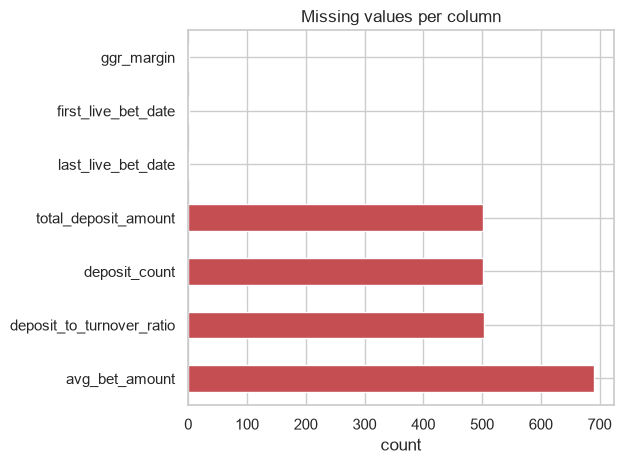

deposit_count == 0 rows : 489
deposit_count NaN  rows : 502
max |avg_bet - turnover/count| on known rows: 0.00


In [12]:
miss = raw.isna().sum() 
miss = miss[miss>0].sort_values(ascending=False)

ax = miss.plot.barh(color="#C44E52")
ax.set_title("Missing values per column") 
ax.set_xlabel("count")

plt.tight_layout()
plt.show()

# Proof that NaN != 0 for deposits, and that avg_bet is recoverable:
print("deposit_count == 0 rows :", int((raw.deposit_count==0).sum()))
print("deposit_count NaN  rows :", int(raw.deposit_count.isna().sum()))

recon = raw.total_turnover / raw.live_bets_count.replace(0, np.nan)
mask = raw.avg_bet_amount.notna() & (raw.live_bets_count>0)

# print("max |avg_bet - turnover/count| on known rows:", float((recon[mask]-raw.avg_bet_amount[mask]).abs().max())) 

max_err = (recon[mask] - raw.avg_bet_amount[mask]).abs().max()
print(f"max |avg_bet - turnover/count| on known rows: {max_err:.2f}")

Two *different* kinds of missingness are handled differently in `src/data.py`:

* **`avg_bet_amount`** is missing (690) and the dictionary defines it as `total_turnover / live_bets_count`. That identity holds exactly on the known rows, so we **reconstruct** the missing values (no information loss) rather than to mean impute.
* **Deposit columns** is missing (~500), here `NaN` and `0` *coexist*, so `NaN` genuinely means *unknown*, not zero. I added a **`deposit_info_missing` flag** (so the model can use "no deposit record" as a signal) and fill with **Deposit columns** with 0.

### 2.2 Target Distribution

- Churn is the minority class (~17%). 
- Mild imbalance but enough that **accuracy is a misleading metric** (a "never churns" model would score 83%). 
- Therefore i will use ROC-AUC / PR-AUC and business lift instead.

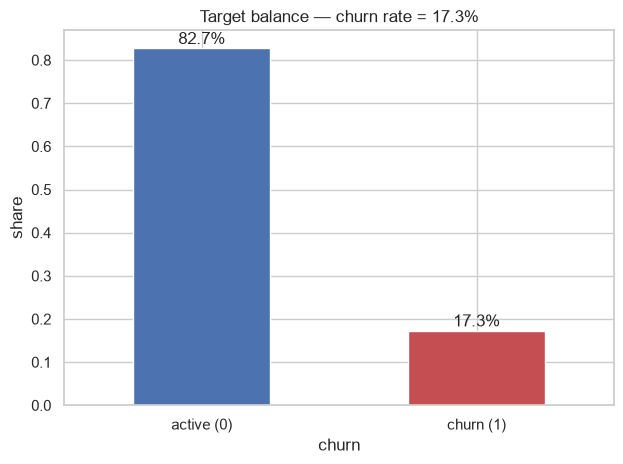

In [13]:
ax = raw[cfg.TARGET].value_counts(normalize=True).sort_index().plot.bar(color=["#4C72B0","#C44E52"])

ax.set_xticklabels(["active (0)","churn (1)"], rotation=0)
ax.set_ylabel("share")

ax.set_title(f"Target balance — churn rate = {raw[cfg.TARGET].mean():.1%}")
for i,v in enumerate(raw[cfg.TARGET].value_counts(normalize=True).sort_index()):
    ax.text(i, v+0.01, f"{v:.1%}", ha="center")
    
plt.tight_layout() 
plt.show()

### 2.3 Distribution of monetary variables

### 
- Money columns are heavily **right skewed** (This means there are few high roller players). 
- Tree models are scale invariant so this will be probably fine for LightGBM. 
- For the linear baseline this likly requires standardization and possibly a log transformation.

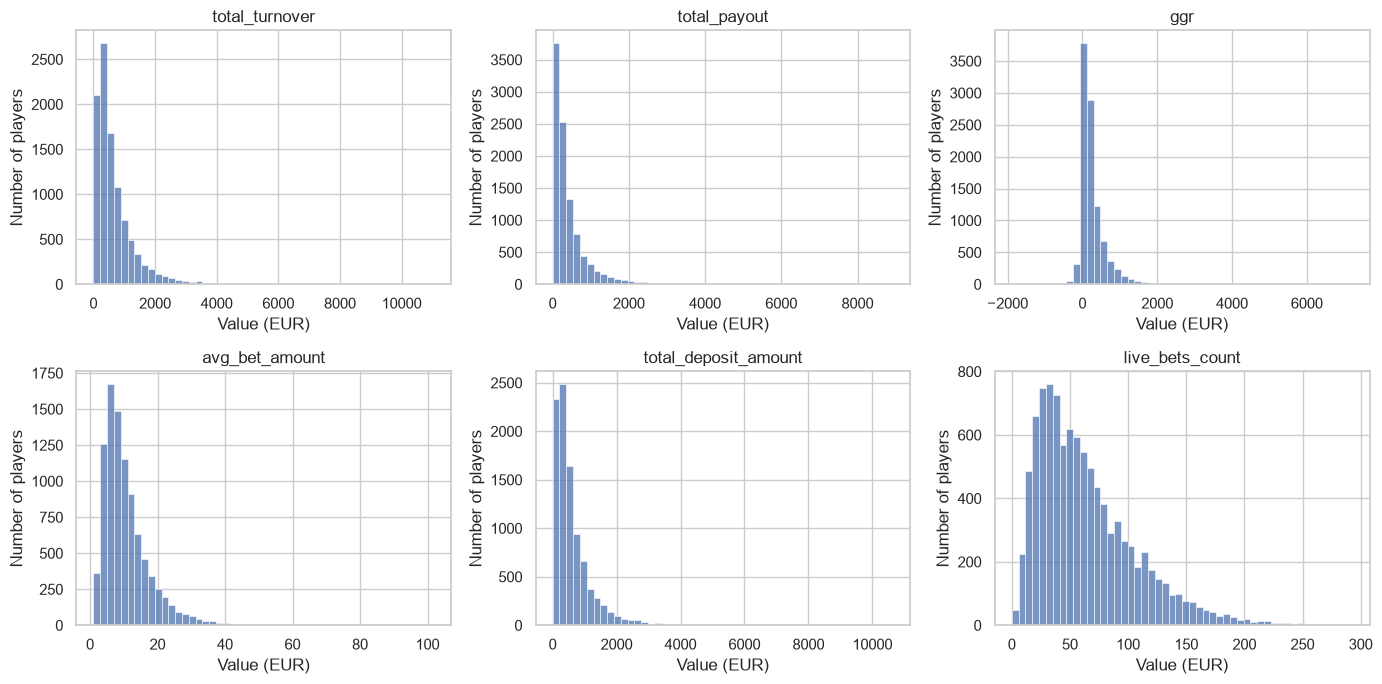

In [14]:
money = ["total_turnover","total_payout","ggr","avg_bet_amount","total_deposit_amount","live_bets_count"]

fig, axes = plt.subplots(2,3, figsize=(14,7))

for ax,col in zip(axes.ravel(), money):
    sns.histplot(raw[col].dropna(), bins=50, ax=ax, color="#4C72B0")
    ax.set_title(col) 
    ax.set_xlabel("Value (EUR)")
    ax.set_ylabel("Number of players")

plt.tight_layout()
plt.show()

### 2.4 What Drives Churn rate. Insightsm

- Here i will go straight for the recency part based on RFM framework (they are the core of the RFM).
- Churn rate by **recency** (days since last bet) and **engagement** (active day rate). These are the two clearest drivers and confirm the **RFM** intuition:
    - Recency is a **strong, nonlinear** signal and churn climbs from ~11% (bet in last 3 days) to ~65% (idle 30+ days).
    - Engagement is strongly **negatively** related to churn.
- Monetary variables such as total_turnover and deposit_count further refine the picture: 
    -lower_value and lower_activity players tend to exhibit higher churn, while more engaged and higher_value players tend to remain active.

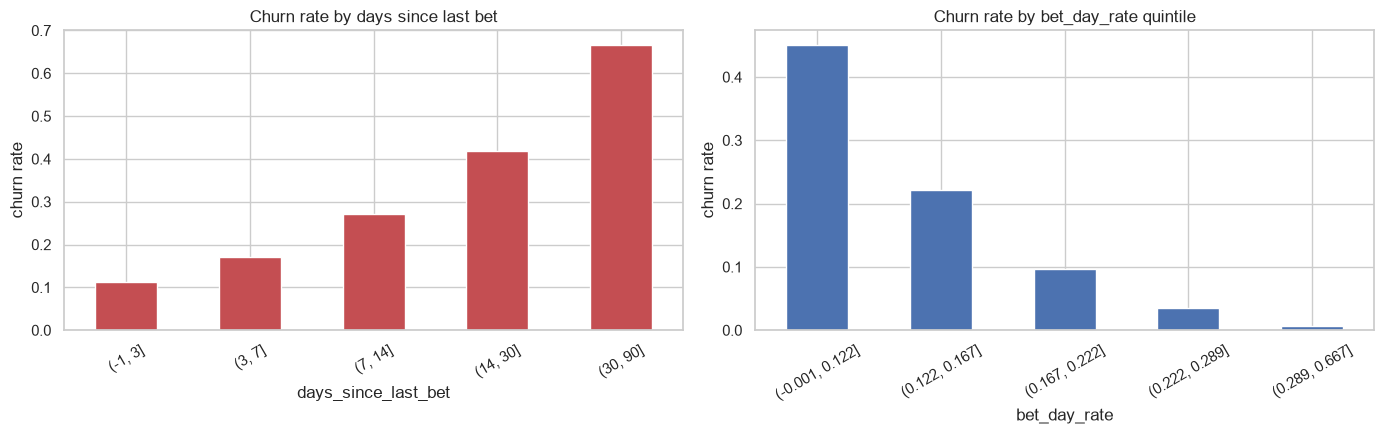

In [15]:
fig, axes = plt.subplots(1,2, figsize=(14,4.5))

rec = raw.groupby(pd.cut(raw.days_since_last_bet,[-1,3,7,14,30,90])).churn.mean()
rec.plot.bar(ax=axes[0], color="#C44E52")

axes[0].set_title("Churn rate by days since last bet")
axes[0].set_ylabel("churn rate") 
axes[0].tick_params(axis="x", rotation=30)

freq = raw.groupby(pd.qcut(raw.bet_day_rate, 5, duplicates="drop")).churn.mean()
freq.plot.bar(ax=axes[1], color="#4C72B0")

axes[1].set_title("Churn rate by bet_day_rate quintile")
axes[1].set_ylabel("churn rate")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

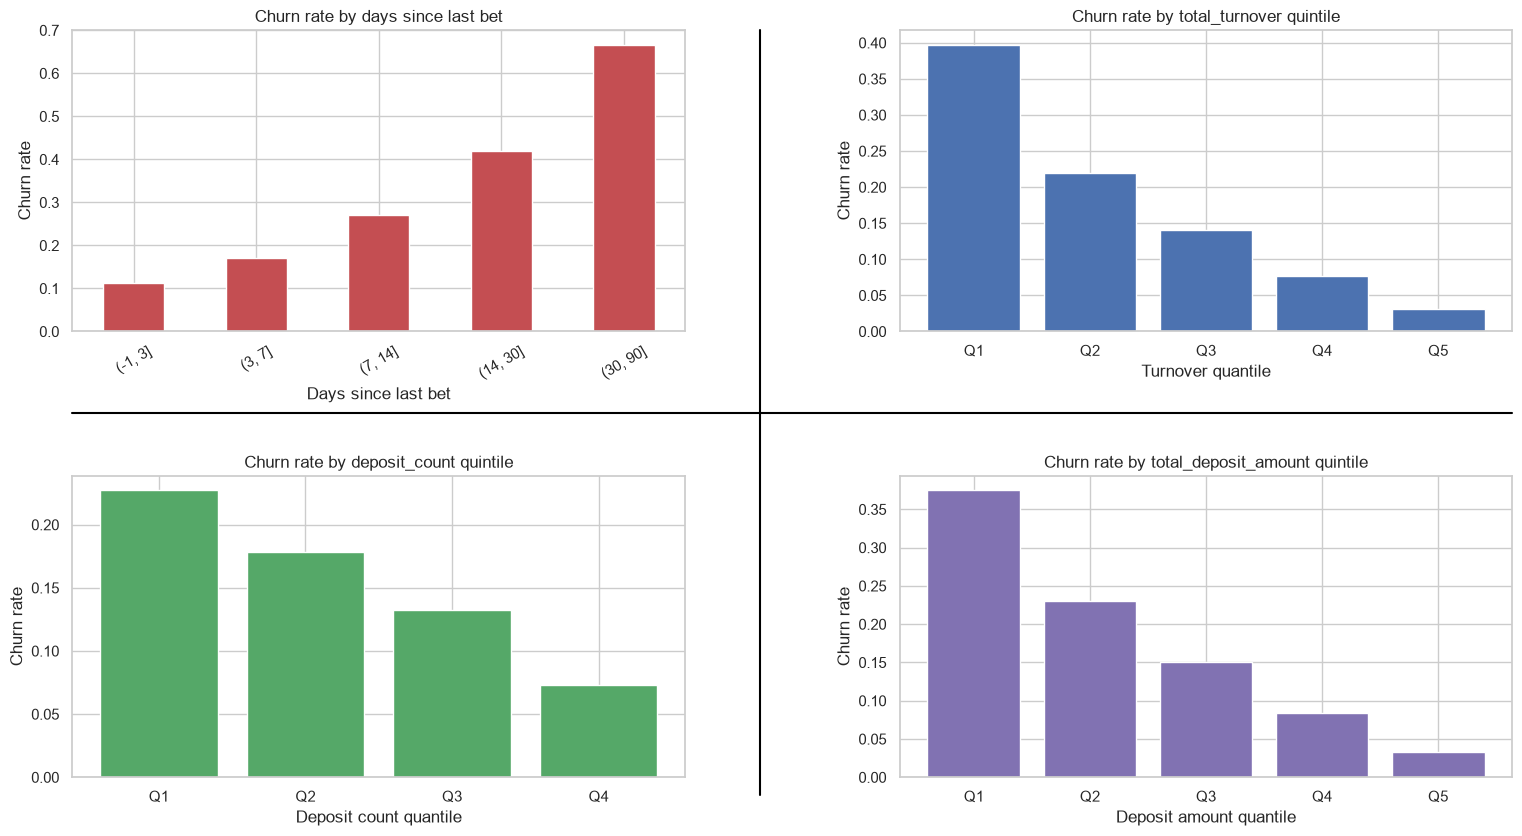

total_turnover bins:
['(-0.001, 212.698]', '(212.698, 368.528]', '(368.528, 590.016]', '(590.016, 1004.952]', '(1004.952, 11056.25]']

deposit_count bins:
['(-0.001, 2.0]', '(2.0, 3.0]', '(3.0, 5.0]', '(5.0, 12.0]']

total_deposit_amount bins:
['(-0.001, 181.614]', '(181.614, 327.204]', '(327.204, 526.292]', '(526.292, 904.83]', '(904.83, 10654.99]']


In [16]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.ravel()

# 1. Recency
rec = raw.groupby(pd.cut(raw.days_since_last_bet, [-1, 3, 7, 14, 30, 90])).churn.mean()
rec.plot.bar(ax=axes[0], color="#C44E52")
axes[0].set_title("Churn rate by days since last bet")
axes[0].set_ylabel("Churn rate")
axes[0].set_xlabel("Days since last bet")
axes[0].tick_params(axis="x", rotation=30)

# 2. Total turnover
turn = raw.groupby(pd.qcut(raw.total_turnover, 5, duplicates="drop")).churn.mean()
axes[1].bar([f"Q{i+1}" for i in range(len(turn))], turn.values, color="#4C72B0")
axes[1].set_title("Churn rate by total_turnover quintile")
axes[1].set_ylabel("Churn rate")
axes[1].set_xlabel("Turnover quantile")

# 3. Deposit count
dep_count = raw.groupby(pd.qcut(raw.deposit_count, 5, duplicates="drop")).churn.mean()
axes[2].bar([f"Q{i+1}" for i in range(len(dep_count))], dep_count.values, color="#55A868")
axes[2].set_title("Churn rate by deposit_count quintile")
axes[2].set_ylabel("Churn rate")
axes[2].set_xlabel("Deposit count quantile")

# 4. Total deposit amount
dep_amt = raw.groupby(pd.qcut(raw.total_deposit_amount, 5, duplicates="drop")).churn.mean()
axes[3].bar([f"Q{i+1}" for i in range(len(dep_amt))], dep_amt.values, color="#8172B2")
axes[3].set_title("Churn rate by total_deposit_amount quintile")
axes[3].set_ylabel("Churn rate")
axes[3].set_xlabel("Deposit amount quantile")

fig.subplots_adjust(left=0.07, right=0.97, top=0.93, bottom=0.10, wspace=0.35, hspace=0.48)
fig.add_artist(Line2D([0.5, 0.5], [0.08, 0.93], transform=fig.transFigure, color="black", linewidth=1.5))
fig.add_artist(Line2D([0.07, 0.97], [0.505, 0.505], transform=fig.transFigure, color="black", linewidth=1.5))

plt.show()


print("total_turnover bins:")
print(turn.index.astype(str).tolist())

print("\ndeposit_count bins:")
print(dep_count.index.astype(str).tolist())

print("\ntotal_deposit_amount bins:")
print(dep_amt.index.astype(str).tolist())

In [36]:
raw['deposit_count'].head()

0    NaN
1    2.0
2    8.0
3    3.0
4    2.0
Name: deposit_count, dtype: float64

In [40]:
raw["deposit_count"].drop_duplicates().sort_values().tolist()

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, nan]

In [41]:
raw["total_deposit_amount"].drop_duplicates().sort_values().tolist()


[0.0,
 28.14,
 33.16,
 33.57,
 33.75,
 34.21,
 35.3,
 35.47,
 36.43,
 36.52,
 38.44,
 40.06,
 40.46,
 40.8,
 41.83,
 42.09,
 42.21,
 42.49,
 42.52,
 43.14,
 43.49,
 43.54,
 43.96,
 44.08,
 44.41,
 44.43,
 44.75,
 45.02,
 45.75,
 45.77,
 45.99,
 46.13,
 46.33,
 46.54,
 46.66,
 47.29,
 47.39,
 47.65,
 47.81,
 47.97,
 48.69,
 48.72,
 49.29,
 49.45,
 49.66,
 49.93,
 50.53,
 51.04,
 51.52,
 51.58,
 52.14,
 52.19,
 52.46,
 52.62,
 52.66,
 52.7,
 53.04,
 53.06,
 53.11,
 53.84,
 53.88,
 54.71,
 55.15,
 55.58,
 55.63,
 56.02,
 56.24,
 56.31,
 56.51,
 56.66,
 56.87,
 57.73,
 57.87,
 58.03,
 58.4,
 58.58,
 58.63,
 58.66,
 58.77,
 59.11,
 59.36,
 59.49,
 59.85,
 59.89,
 60.11,
 60.3,
 60.47,
 60.79,
 61.43,
 61.69,
 62.12,
 62.15,
 62.22,
 62.24,
 62.31,
 62.64,
 62.68,
 62.76,
 62.82,
 63.22,
 63.97,
 64.5,
 64.68,
 64.8,
 64.83,
 64.89,
 64.91,
 65.03,
 65.06,
 65.07,
 65.16,
 65.24,
 65.34,
 65.54,
 65.62,
 65.66,
 66.34,
 66.51,
 66.53,
 66.77,
 67.16,
 67.32,
 67.34,
 67.83,
 68.03,
 68.07,
 

### 2.5 Correlation

- Here i am looking for spearman correlation between variables to make educated guess for skewed data. 
- This will be only used to help with feature engineering process, but for feature importance most impact will come from PR-AUC, SHAP, top-k analysis.

- Note for later analysis:
    - Near duplicate pair: days_active_in_observation ~ bet_day_rate (1.00). Likely mathematically derived from one another. 
    Solution would be to keep one, or engineer into a single feature.
    - live_bets_count strongly overlaps with the pair above (0.97 both). This shoudl be candidate for consolidation into a single "activity/engagement" feature.
    - **(total_turnover, total_deposit_amount, total_payout, live_bets_count, bet_day_rate)** is internally correlated (0.6-0.9 range) 
      and also the strongest (negative) correlates of churn individually.

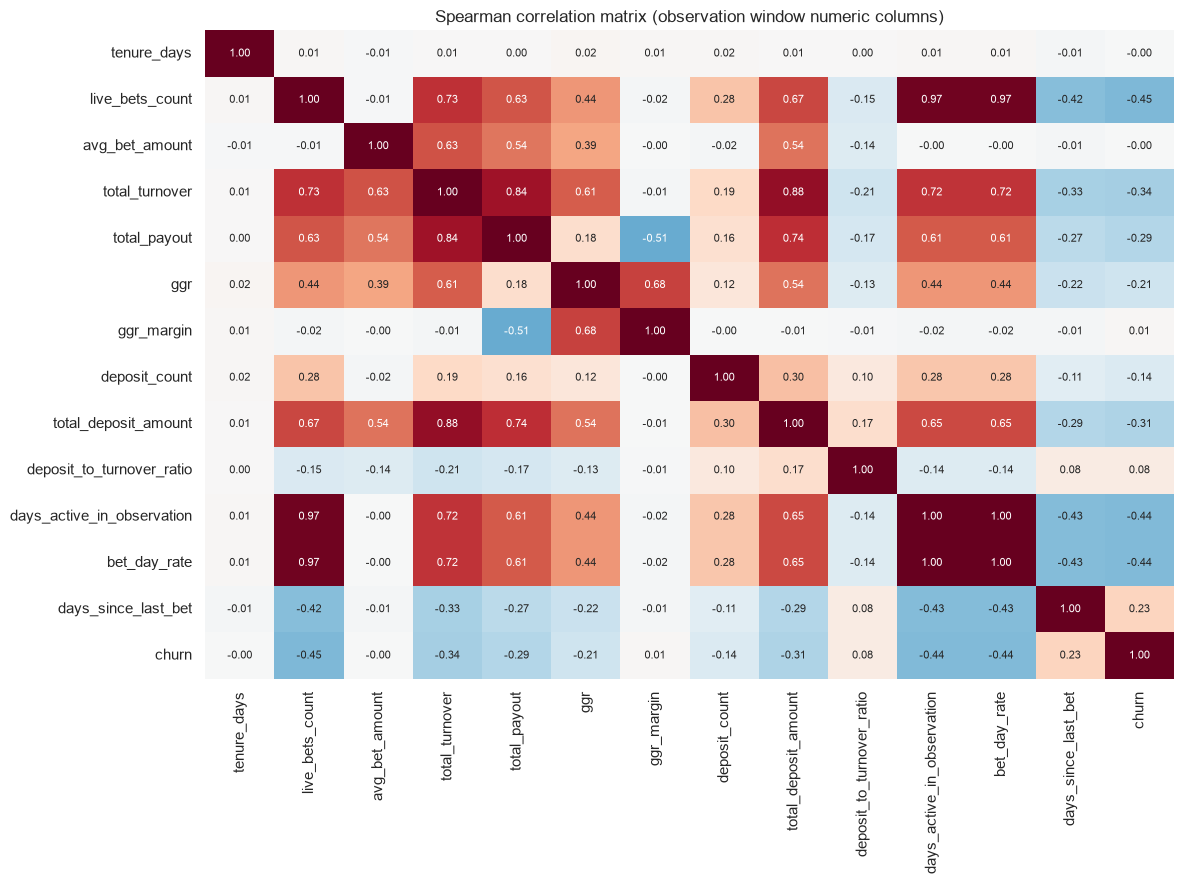

In [17]:
num = raw.select_dtypes("number").drop(columns=["live_bets_count_outcome_window"])

corr = num.corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, square=False, annot=True, fmt=".2f", annot_kws={"size": 8}, cbar=False)

plt.title("Spearman correlation matrix (observation window numeric columns)")
plt.tight_layout()
plt.show()

### 2.6 Lekage audit.

Some features will be removed because they are predicting future or are answers to target variable.

So base ond DATA_DICTIONARY.md:
- `live_bets_count_outcome_window` will be **DROPDED**. The target is literally derived from it. Using it is same as looking into the future.
- `observation_start/end_date` will be **DROPED**. Constant for every row in this single snapshot so no signal.
- `registration_date`, `first/last_live_bet_date` will be **TRANSFORMED**. Raw dates are useless to the model. 
So it will be converted into numeric recency/tenure features, then dropped.
- `days_since_last_bet` will be **KEPT (watch)**. Measured at the snapshot; it is the strongest predictor. I wil keep it but try it does not *entirely* dominate.

All of this is codded in `src/config.py::LEAKAGE_COLS` so it is auditable.

In [18]:
print("Dropped as leakage / constant:")
for c,why in cfg.LEAKAGE_COLS.items(): print(f"  - {c:32s} : {why}")

# Sanity check: the leakage column is almost a perfect proxy for the target.
print("\nAUC of raw 'outcome_window' count as a churn predictor (should be ~1.0 = obvious leak):")

from sklearn.metrics import roc_auc_score
print(round(roc_auc_score(raw.churn, -raw.live_bets_count_outcome_window), 4))

Dropped as leakage / constant:
  - live_bets_count_outcome_window   : target is derived from this column
  - observation_start_date           : constant (single snapshot)
  - observation_end_date             : constant (single snapshot)

AUC of raw 'outcome_window' count as a churn predictor (should be ~1.0 = obvious leak):
1.0


## 3.0 Feature Engineering (RFM framework)

This part will be engineered in `src/features.py`.

RFM  explanation (Recency, Frequency/engagement, Monetary/Value)

**Recency** *how long since active, relative to who they are*
- `recency_ratio` = idle days / tenure. 10 idle days means more for a 2 week old account than for a veteran.
- `days_since_first_bet`, `active_span_days` = onboarding age and how long their activity spanned.
- `last_bet_window_position` = how early in the window players went quiet.

**Frequency / engagement**
- `bets_per_active_day` = intensity when they do play.
- `activity_consistency` = active days spread across their span (steady vs one burst).

**Monetary / value**
- `turnover_per_active_day`, `turnover_per_bet`, `deposit_per_bet` = spend intensity normalised.
- `net_cash_flow` = deposits − payouts (operators cash view); `has_no_deposit`.
- `turnover_per_tenure_day`, `is_new_player` = value vs lifecycle stage.

Normalising raw counts by the players own tenure / active days lets a casual, newcomer and a heavy veteran be compared fairly.

In [19]:
df = load_clean()
feat = add_features(df)
new_cols = [c for c in feat.columns if c not in df.columns]

print("Engineered features:", new_cols)

feat[["user_id", "days_since_last_bet", "recency_ratio", "bets_per_active_day", "turnover_per_active_day", "net_cash_flow", "is_new_player"]].head()

Engineered features: ['recency_ratio', 'days_since_first_bet', 'active_span_days', 'last_bet_window_position', 'bets_per_active_day', 'activity_consistency', 'turnover_per_active_day', 'turnover_per_bet', 'deposit_per_bet', 'net_cash_flow', 'has_no_deposit', 'turnover_per_tenure_day', 'is_new_player']


,user_id,days_since_last_bet,recency_ratio,bets_per_active_day,turnover_per_active_day,net_cash_flow,is_new_player
0,USER_10000,5,0.026178,2.875000,5.836250,-27.74,0
1,USER_10001,10,0.020408,3.071429,16.032857,32.20,0
2,USER_10002,3,0.005848,3.076923,21.753846,188.82,0
3,USER_10003,0,0.000000,3.739130,38.700000,287.16,0
4,USER_10004,1,0.002092,3.416667,10.420833,-10.57,0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   user_id                         10000 non-null  str           
 1   registration_date               10000 non-null  datetime64[us]
 2   observation_start_date          10000 non-null  datetime64[us]
 3   observation_end_date            10000 non-null  datetime64[us]
 4   last_live_bet_date              9999 non-null   datetime64[us]
 5   first_live_bet_date             9999 non-null   datetime64[us]
 6   tenure_days                     10000 non-null  int64         
 7   live_bets_count                 10000 non-null  int64         
 8   avg_bet_amount                  9999 non-null   float64       
 9   total_turnover                  10000 non-null  float64       
 10  total_payout                    10000 non-null  float64       
 11  ggr           

## 4.0 Modeling

### 4.1 Imports for modeling

In [21]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

In [ ]:
X, y = build_feature_matrix(load_clean())
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=cfg.RANDOM_STATE)

print("train:", X_tr.shape, "  test:", X_te.shape)

logit = Pipeline([("imp", SimpleImputer(strategy="median")),
                  ("sc", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])

lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.03, max_depth=3, num_leaves=8,
                          min_child_samples=150, subsample=0.8, colsample_bytree=0.8,
                          reg_lambda=1.0, random_state=cfg.RANDOM_STATE, verbose=-1)

train: (8000, 27)   test: (2000, 27)


### 4.2 Cross Validation stability check

In [38]:
cv = StratifiedKFold(5, shuffle=True, random_state=cfg.RANDOM_STATE)

scores = {}

for name, mdl in [("LogReg", logit), ("LightGBM", lgbm)]:
    scores[f"{name} ROC-AUC"] = cross_val_score(mdl, X_tr, y_tr, cv=cv, scoring="roc_auc")
    scores[f"{name} PR-AUC"]  = cross_val_score(mdl, X_tr, y_tr, cv=cv, scoring="average_precision")
    
ev.cv_stability(scores)

,mean,std
LogReg ROC-AUC,0.8353,0.0039
LogReg PR-AUC,0.5002,0.0122
LightGBM ROC-AUC,0.8294,0.0024
LightGBM PR-AUC,0.4845,0.0116


### 4.3 Fit on train, evaluate on the held-out test set

In [28]:
logit.fit(X_tr, y_tr)
lgbm.fit(X_tr, y_tr)

p_lr = logit.predict_proba(X_te)[:,1]
p_gb = lgbm.predict_proba(X_te)[:,1]

res = pd.DataFrame({"LogReg": ev.threshold_free_metrics(y_te, p_lr), "LightGBM": ev.threshold_free_metrics(y_te, p_gb)}).T
res.round(4)

,roc_auc,pr_auc,brier
LogReg,0.8550,0.5333,0.1621
LightGBM,0.8481,0.5104,0.1078


## 5. Evaluation

### 5.1 ROC & Precision-Recall curves

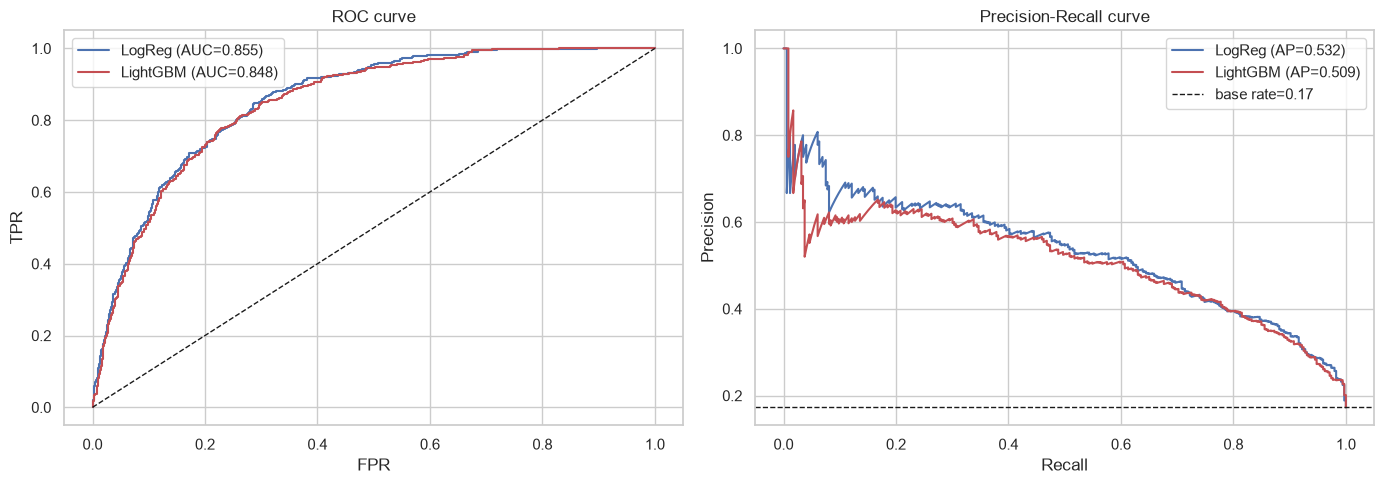

In [29]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1,2, figsize=(14,5))

for name,p,c in [("LogReg",p_lr,"#4C72B0"),("LightGBM",p_gb,"#C44E52")]:
    fpr,tpr,_ = roc_curve(y_te,p); axes[0].plot(fpr,tpr,label=f"{name} (AUC={auc(fpr,tpr):.3f})", color=c)
    pr,rc,_ = precision_recall_curve(y_te,p); axes[1].plot(rc,pr,label=f"{name} (AP={auc(rc,pr):.3f})", color=c)

axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set(xlabel="FPR",ylabel="TPR",title="ROC curve")
axes[0].legend()
axes[1].axhline(y_te.mean(),ls="--",c="k",lw=1,label=f"base rate={y_te.mean():.2f}")
axes[1].set(xlabel="Recall",ylabel="Precision",title="Precision-Recall curve")
axes[1].legend()

plt.tight_layout() 
plt.show()

### 5.2 Retention targeting, lift @ top-k


In [30]:
ev.topk_report(y_te, p_gb)

,top_k,n_contacted,precision,recall,lift
0,5%,100,0.640,0.185,3.70
1,10%,200,0.595,0.344,3.44
2,20%,400,0.505,0.584,2.92


### 5.3 Calibration


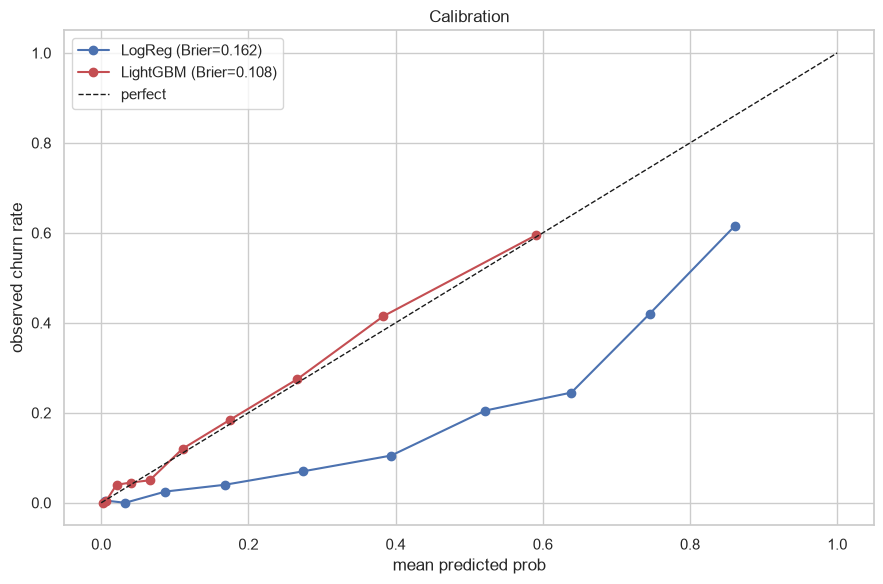

In [34]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(9,6))

for name,p,c in [("LogReg",p_lr,"#4C72B0"),("LightGBM",p_gb,"#C44E52")]:
    fo,mp = calibration_curve(y_te,p,n_bins=10,strategy="quantile")
    plt.plot(mp,fo,"o-",label=f"{name} (Brier={ev.threshold_free_metrics(y_te,p)['brier']:.3f})",color=c)

plt.plot([0,1],[0,1],"k--",lw=1,label="perfect")
plt.xlabel("mean predicted prob")
plt.ylabel("observed churn rate")
plt.title("Calibration")
plt.legend()

plt.tight_layout()
plt.show()

## 6. Explainability, SHAP

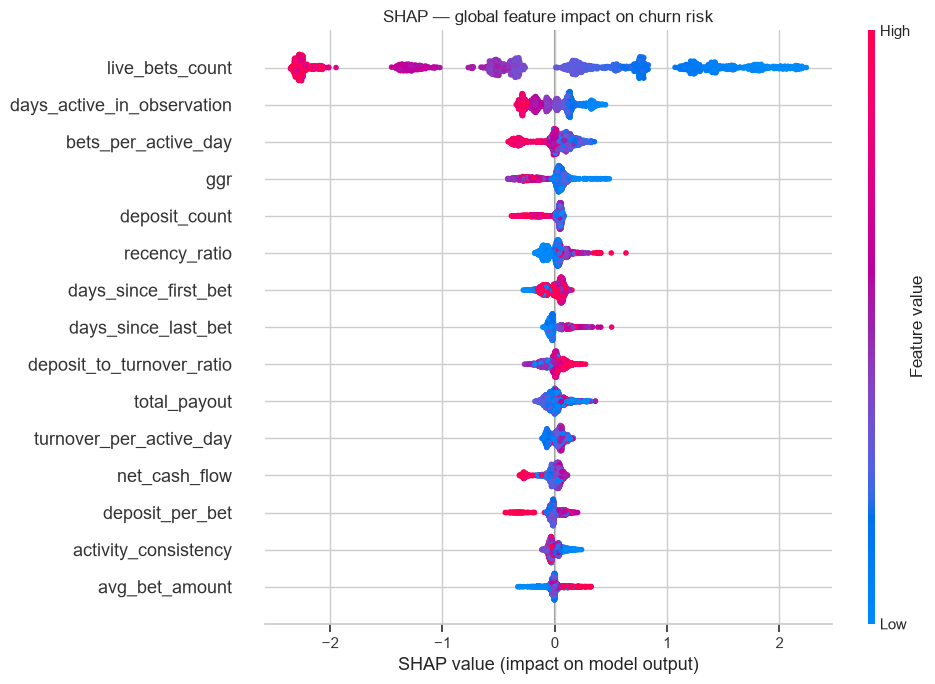

In [35]:
import shap

explainer = shap.TreeExplainer(lgbm)

sv = explainer.shap_values(X_te)
sv1 = sv[1] if isinstance(sv, list) else sv   # positive class

shap.summary_plot(sv1, X_te, show=False, max_display=15, plot_size=(10,7))
plt.title("SHAP — global feature impact on churn risk")
plt.tight_layout()
plt.show()